In [73]:
from util import go_to_project_root
go_to_project_root()

CWD changed to the project root: /home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1


# Pregunta 3

In [74]:
import numpy as np
import matplotlib.pyplot as plt 

from source.models.arma import ARMA
from source.utils import plot as uplot 
from source.data.loaders import create_dataset
from source.optimize.conditionalss import conditional_square_sum
from source.optimize.likelihood import maximum_likelihood_estimation
from source.optimize.hrissanen import boostrap_hannan_rissanen

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Analisis exploratorio

El archivo `base_25.xls` contiene información mensual del 
- IPC (P), 
- IMACEC (Y), 
- Tasa de Política Monetaria (I). 

La funcion `create_dataset` lee los datos y transforma cada serie segun las siguintes definiciones: 
- $\pi_t = \ln(P_t/P_{t-1})$ (Tasa de cambio del IPC) 
- $y_t = \ln(Y_t/Y_{t-1})$ (Tasa de cambio del IMACEC)
- $i_t = I_t/100$. (Tasa de politica monetaria)

In [3]:
dataset = create_dataset('./data/base_25.xls')
dataset.keys()

[INFO] Data loaded successfully!


dict_keys(['t', 'pi_t', 'y_t', 'i_t'])

### Evaluando estacionalidad

Para evaluar estacionalidad utilizaremos 3 enfoques: 
1. Inspeccion visual de la serie de tiempo 
2. Inspeccion visual de la Funcion de Autocorrelacion (ACF) y Funcion de Autocorrelacion Parcial (PACF)
3. Analisis de medidas de tendencia central

Partimos por observar las series de tiempo, 

✅ Successfully saved figure to ./presentation/figures/p3/raw_series.pdf


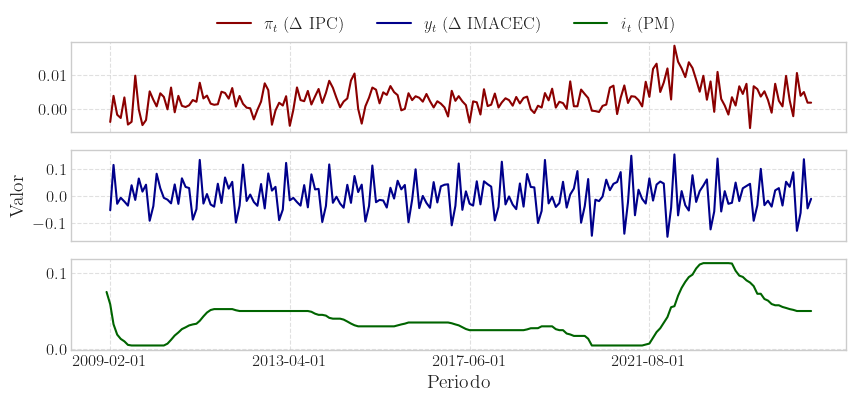

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 4), sharex=True)
fig, axes = uplot.plot_series_p3(dataset, fig, axes)
uplot.save_figure(fig, './presentation/figures/p3/raw_series.pdf')

A simple vista podemos ver que la tasa de cambio del IMACEC exhibe peaks periodicos, potencialmente patrones estacionales. 

##### ACF y PACF en la Inflacion $(\pi_t)$

✅ Successfully saved figure to ./presentation/figures/p3/acf_pacf_ipc.pdf


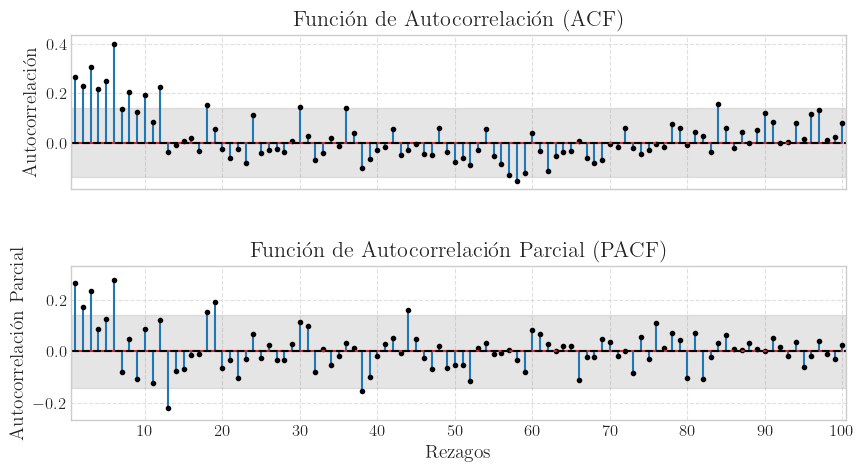

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={'hspace':0.5})
fig, axes = uplot.plot_acf_pacf(dataset['pi_t'], lags= 100, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/acf_pacf_ipc.pdf')

Al observar la figura podemos ver que no existen patrones significativos que permitan afirmar una estacionalidad evidente. Sin embargo desde la ACF se desprende que aproximadamente hasta el rezago 20 se tiene una autocorrelacion significativa entre las obervaciones. Lo anterior se confirma con el PACF el cual muestra los rezagos ajustados desde un AR truncado. Como se puede ver en la iamgen los valores significativos comprenden un rango menor que 20

##### ACF y PACF en el IMACEC

✅ Successfully saved figure to ./presentation/figures/p3/acf_pacf_imacec.pdf


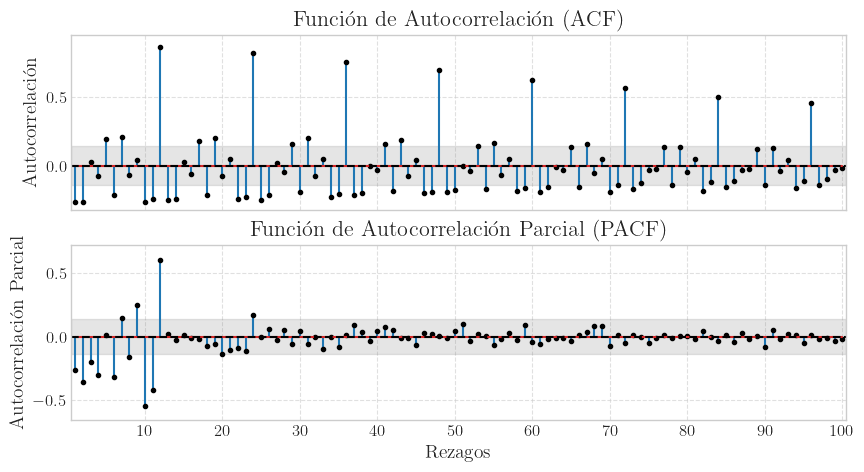

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
fig, axes = uplot.plot_acf_pacf(dataset['y_t'], lags= 100, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/acf_pacf_imacec.pdf')

Desde el ACF se ve una estacionalidad significativa cada $\sim 12$ rezagos. 

Desde el PACF podemos observar que hasta el rezago $\sim 12$ existe significancia de correlacion despues de haber contorolado por los rezagos anteriores. 

##### ACF y PACF en la Tasa de Politica Monetaria ($i_t$)

✅ Successfully saved figure to ./presentation/figures/p3/acf_pacf_tpm.pdf


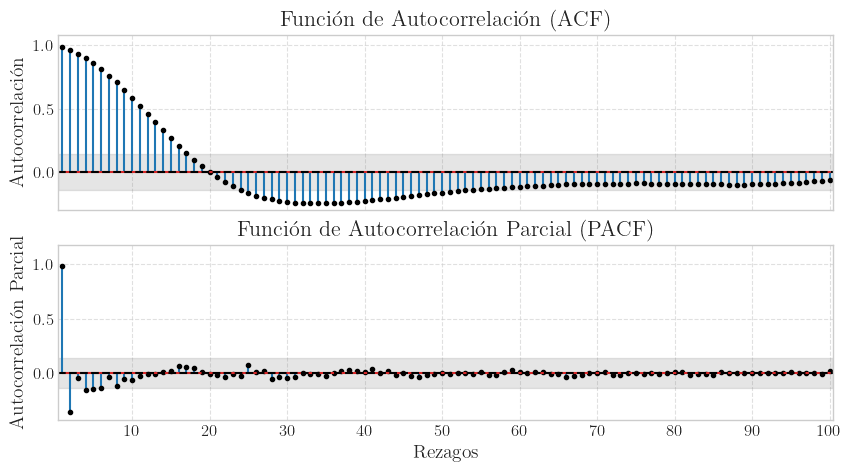

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
fig, axes = uplot.plot_acf_pacf(dataset['i_t'], lags= 100, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/acf_pacf_tpm.pdf')

La ACF para la tasa de politica monetaria muestra un decaimiento muy lento y gradual. Esto indica que el proceso es altamente no estacionario, y con alta persistencia. En otras palabras, el valor de la TPM en un periodo esta fuertemente correlacionado con sus valores en periodos anteriores. Una decisión de política monetaria de hoy tiene efectos duraderos en el futuro lo cual impidie que la tasa revierta a un promedio historico.

Desde la PACF vemos un pico muy grande en el primer rezago y un efecto negativo en el segundo, pero de menor magnitud. Esto sugiere que el proceso es similar a un $AR(\sim 1)$ donde el valor del futuro depende altamente del periodo inmediatamente anterior y los otros valores son irrelevantes para el valor actual.

/home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1/source/utils/plot.py:271: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  data=df, ax=ax,


✅ Successfully saved figure to ./presentation/figures/p3/med_ipc.pdf


/home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1/source/utils/plot.py:271: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  data=df, ax=ax,


✅ Successfully saved figure to ./presentation/figures/p3/med_imacec.pdf


/home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1/source/utils/plot.py:271: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  data=df, ax=ax,


✅ Successfully saved figure to ./presentation/figures/p3/med_tpm.pdf


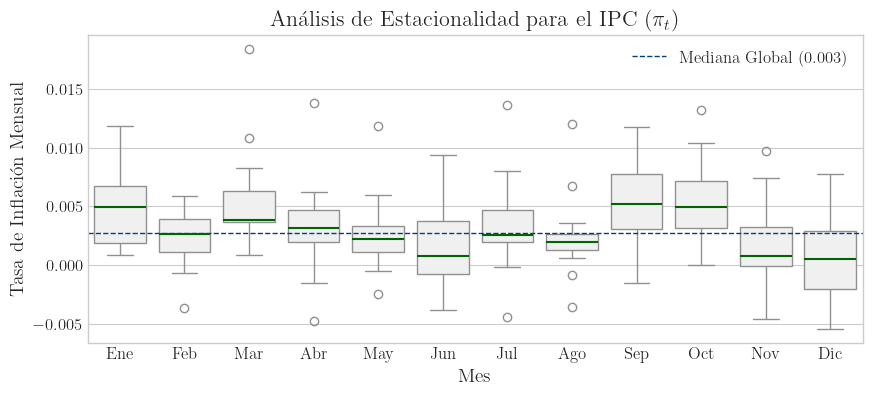

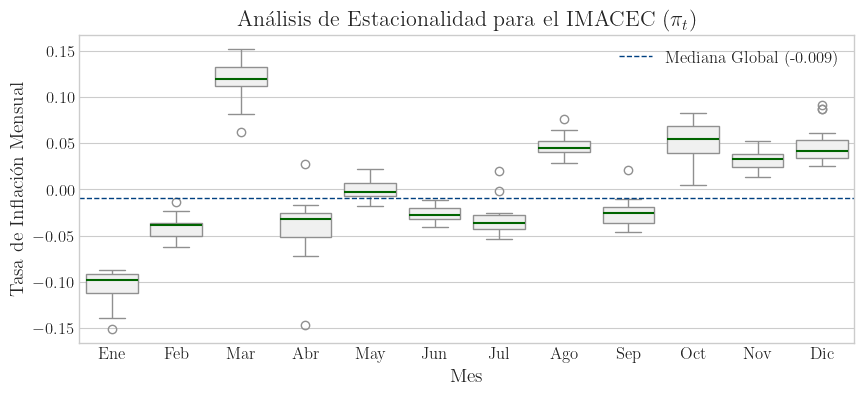

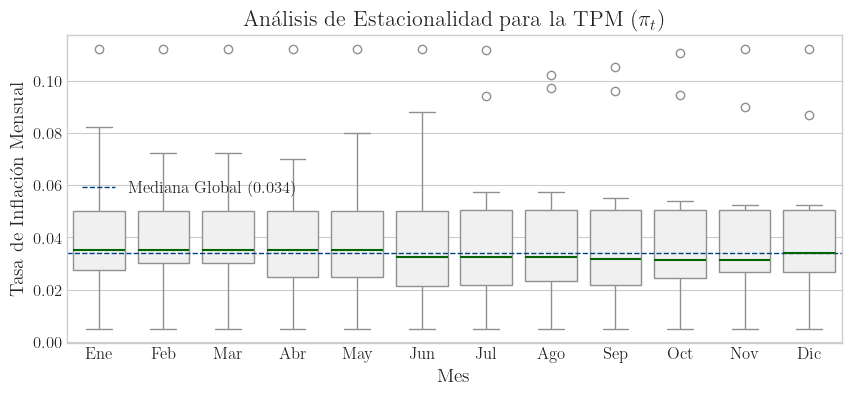

In [32]:
fig, ax = plt.subplots(figsize=(10, 4))
uplot.plot_monthly_boxplot(dataset['t'][1:], dataset['pi_t'], 
                           title=r'Análisis de Estacionalidad para el IPC ($\pi_t$)',
                           ylabel='Tasa de Inflación Mensual',
                           fig=fig, ax=ax)
uplot.save_figure(fig, './presentation/figures/p3/med_ipc.pdf')
fig, ax = plt.subplots(figsize=(10, 4))
uplot.plot_monthly_boxplot(dataset['t'][1:], dataset['y_t'], 
                           title=r'Análisis de Estacionalidad para el IMACEC ($\pi_t$)',
                           ylabel='Tasa de Inflación Mensual',
                           fig=fig, ax=ax)
uplot.save_figure(fig, './presentation/figures/p3/med_imacec.pdf')

fig, ax = plt.subplots(figsize=(10, 4))
uplot.plot_monthly_boxplot(dataset['t'], dataset['i_t'], 
                           title=r'Análisis de Estacionalidad para la TPM ($\pi_t$)',
                           ylabel='Tasa de Inflación Mensual',
                           fig=fig, ax=ax)
uplot.save_figure(fig, './presentation/figures/p3/med_tpm.pdf')

#### Determinando el p y q

Desde el procedimiento anterior podemos decir que los valores para $p$ y $q$ oscilan entre los 0 y 15 rezagos. Sin embargo, para evaluar correctamente utilizaremos el metodo Hannan Rissanen.

In [39]:
dataset['pi_t'].shape

(196,)

In [77]:
results_ipc = boostrap_hannan_rissanen(y_data=dataset['pi_t'], 
                                   iterations=100, 
                                   j_max=20, 
                                   criteria='hqic')
results_imacec = boostrap_hannan_rissanen(y_data=dataset['y_t'], 
                                   iterations=100, 
                                   j_max=20, 
                                   criteria='hqic')
results_tpm = boostrap_hannan_rissanen(y_data=dataset['i_t'], 
                                   iterations=100, 
                                   j_max=20, 
                                   criteria='hqic')

Looking for the best parameters:   0%|          | 0/100 [00:00<?, ?it/s]/home/epsilon/.conda/envs/macro/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
Looking for the best parameters:  20%|██        | 20/100 [00:01<00:06, 12.29it/s]/home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1/source/models/ar.py:65: RuntimeWarning: invalid value encountered in sqrt
  self._unconditional_std = np.sqrt(gamma_0)
Looking for the best parameters:   2%|▏         | 2/100 [00:00<00:12,  7.67it/s]/home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1/source/optimize/likelihood.py:140: RuntimeWarning: overflow encountered in square
  sum_of_squared_residuals = np.sum(errors[start_t:]**2)
Looking for the best parameters: 100%|██████████| 100/100 [00:10<00:00,  9.29it/s]


✅ Successfully saved figure to ./presentation/figures/p3/pq_ipc.pdf
✅ Successfully saved figure to ./presentation/figures/p3/pq_imacec.pdf
✅ Successfully saved figure to ./presentation/figures/p3/pq_tpm.pdf


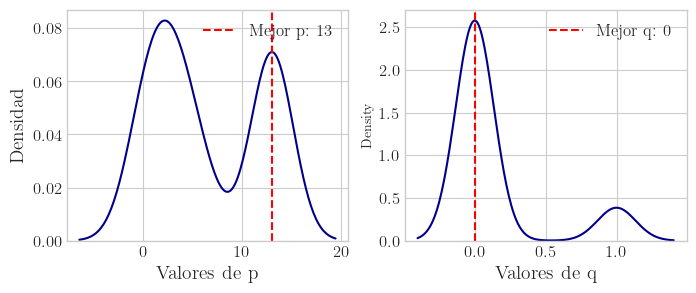

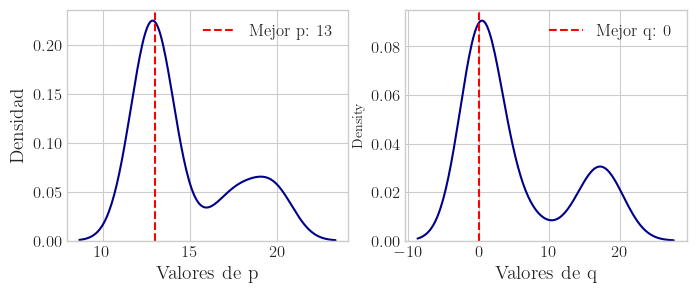

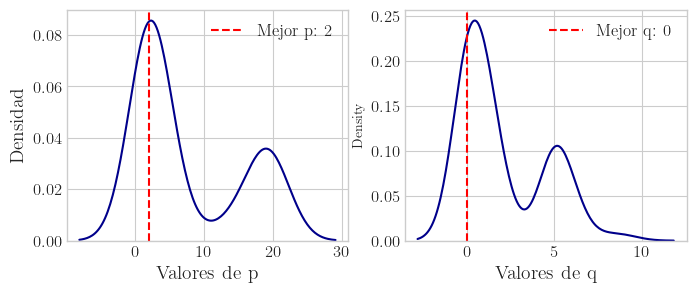

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
fig, axes = uplot.plot_hannan_rissanen_results(results=results_ipc, 
                                               fig=fig, 
                                               axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/pq_ipc.pdf')

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
fig, axes = uplot.plot_hannan_rissanen_results(results=results_imacec, 
                                               fig=fig, 
                                               axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/pq_imacec.pdf')

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
fig, axes = uplot.plot_hannan_rissanen_results(results=results_tpm, 
                                               fig=fig, 
                                               axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/pq_tpm.pdf')

In [42]:
predmodel_css = conditional_square_sum(arma_model, y_data=dataset['pi_t'])
predmodel_mle = maximum_likelihood_estimation(arma_model, dataset['pi_t'])

In [71]:
nobs = dataset['pi_t'].shape[0]
y_pred_0 = arma_model.sample(n_samples=nobs, initial_values=dataset['pi_t'][:2])
y_pred_1 = predmodel_css.sample(n_samples=nobs, initial_values=dataset['pi_t'][:2])
y_pred_2 = predmodel_mle.sample(n_samples=nobs, initial_values=dataset['pi_t'][:2])

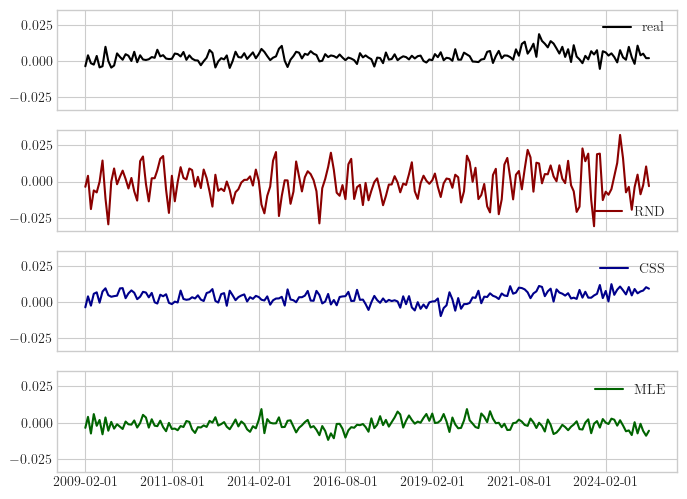

In [86]:
fig, axes = plt.subplots(4, 1, figsize=(8,6), sharex=True, sharey=True)
import pandas as pd
x_labels_year = pd.Series(dataset['t'][1:]).dt.date
x_labels_tick = x_labels_year.unique()[::30]

axes[0].plot(x_labels_year, dataset['pi_t'], linestyle='-', color='k', label='real')
axes[1].plot(x_labels_year, y_pred_0, linestyle='-', color='darkred', label='RND')
axes[2].plot(x_labels_year, y_pred_1, linestyle='-', color='darkblue', label='CSS')
axes[3].plot(x_labels_year, y_pred_2, linestyle='-', color='darkgreen', label='MLE')

for i in range(4):
    axes[i].legend()
    axes[i].set_xticks(x_labels_tick)
    axes[i].set_xticklabels(x_labels_tick, rotation=0)

plt.show()